In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import time

df_long = pd.read_csv("df_long_clean_w_reagents_cleaned.csv")

print(df_long.columns)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Index(['Unnamed: 0', 'reaction_class', 'description', 'reagents_used',
       'confidence', 'reasoning', 'pub_year', 'source_folder', 'rxnCategory',
       'rxnSubcategory', 'rxnCode', 'problemCategory', 'problemDescription',
       'solutionCategory', 'solutionDescription', 'solutionCat_L1',
       'solutionCat_L2', 'reagents_used_clean', 'n_reagents_clean'],
      dtype='object')


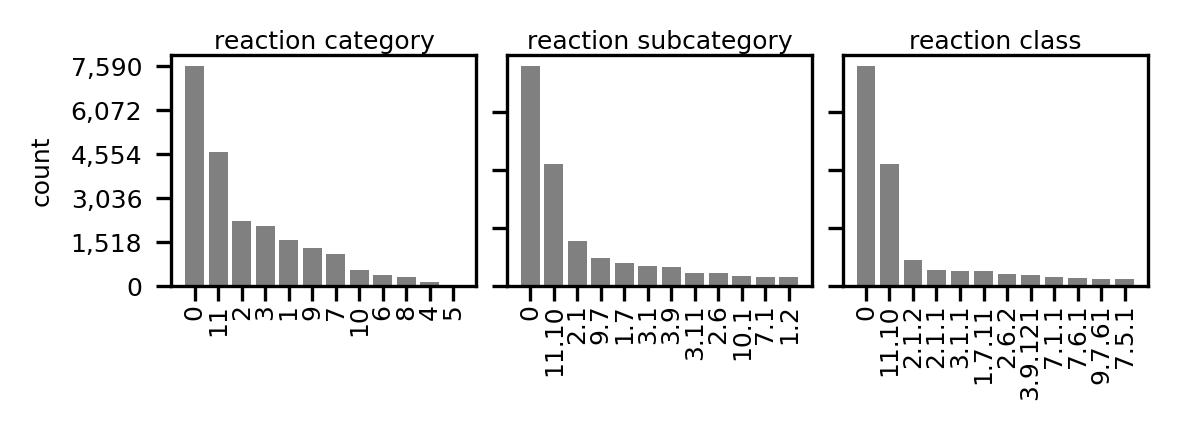

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

reverse_rxn_code_lookup = {}
for i,k in df_long.iterrows():
    rc = k["reaction_class"]
    rCat = k["rxnCategory"]
    rSubcat = k["rxnSubcategory"]
    rcode = k["rxnCode"]
    
    s = rcode.split(".")
    if rCat not in reverse_rxn_code_lookup:
        reverse_rxn_code_lookup[rCat] = s[0]
    if rSubcat not in reverse_rxn_code_lookup:
        reverse_rxn_code_lookup[rSubcat] = ".".join(s[0:2])
    if rc not in reverse_rxn_code_lookup:
        reverse_rxn_code_lookup[rc] = rcode
    # if rc not in reverse_rxn_code_lookup:
# for rr in reverse_rxn_code_lookup:
    # print(rr, reverse_rxn_code_lookup[rr])

def plot_top_n_reaction_taxonomy_bars(
    df,
    top_n=10,
    *,
    figsize=(4.2, 1),
    save_path=None,
    color="grey",
):
    """Plot top-N frequencies for reaction_class, rxnSubcategory, and rxnCategory as 3 horizontal subplots."""
    cols = ["rxnCategory", "rxnSubcategory", "reaction_class"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    titles = ["reaction category", "reaction subcategory", "reaction class"]
    with plt.rc_context({
        "font.size": 6,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
    }):
        fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=300, sharey=False)
        for ax, col in zip(axes, cols):
            counts = df[col].dropna().astype(str).value_counts().head(top_n)
            labels = counts.index
            values = counts.values
            
            new_labels = []
            for l in labels:
                new_labels.append(reverse_rxn_code_lookup[l])
            labels = new_labels
                
                
            # print(counts.values)
            # print(len(values))
            # print(values)
            bars = ax.bar(labels, values, color=color)
            ax.set_title(titles[cols.index(col)], fontsize=6, y=0.92)
            ax.tick_params(axis="both", labelsize=6)
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=90, ha="center", fontsize=6, y=0.05)
            ax.set_ylabel("", fontsize=6)
            ax.set_xlabel("")
            # ax.set_yticks([])
            ax.set_yticklabels([])
            

        axes[0].set_ylabel("count", fontsize=6)
        axes[0].set_yticks(range(0, max(values) + 1, max(1, max(values) // 5)))
        axes[0].set_yticklabels([f"{v:,}" for v in range(0, max(values) + 1, max(1, max(values) // 5))], fontsize=6)
        # axes[1].set_xlabel("reaction code", fontsize=6, y=0.15)
            # for bar, value in zip(bars, values):
            #     ax.text(
            #         bar.get_x() + bar.get_width() / 2,
            #         bar.get_height() + 50,
            #         f"{value:,}",
            #         ha="center",
            #         va="bottom",
            #         fontsize=5,
            #     )

        # plt.tight_layout()
        # plt.suptitle("top 10 classes of reactions extracted", fontsize=6, y=1.15)
        
        plt.subplots_adjust(wspace=0.1)
        if save_path is not None:
            fig.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.01,
            )

    return fig, axes


# Example usage:
fig, axes = plot_top_n_reaction_taxonomy_bars(
    df_long,
    top_n=12,
    save_path="figout/topN_reaction_taxonomy_bars2.png",
)
plt.show()

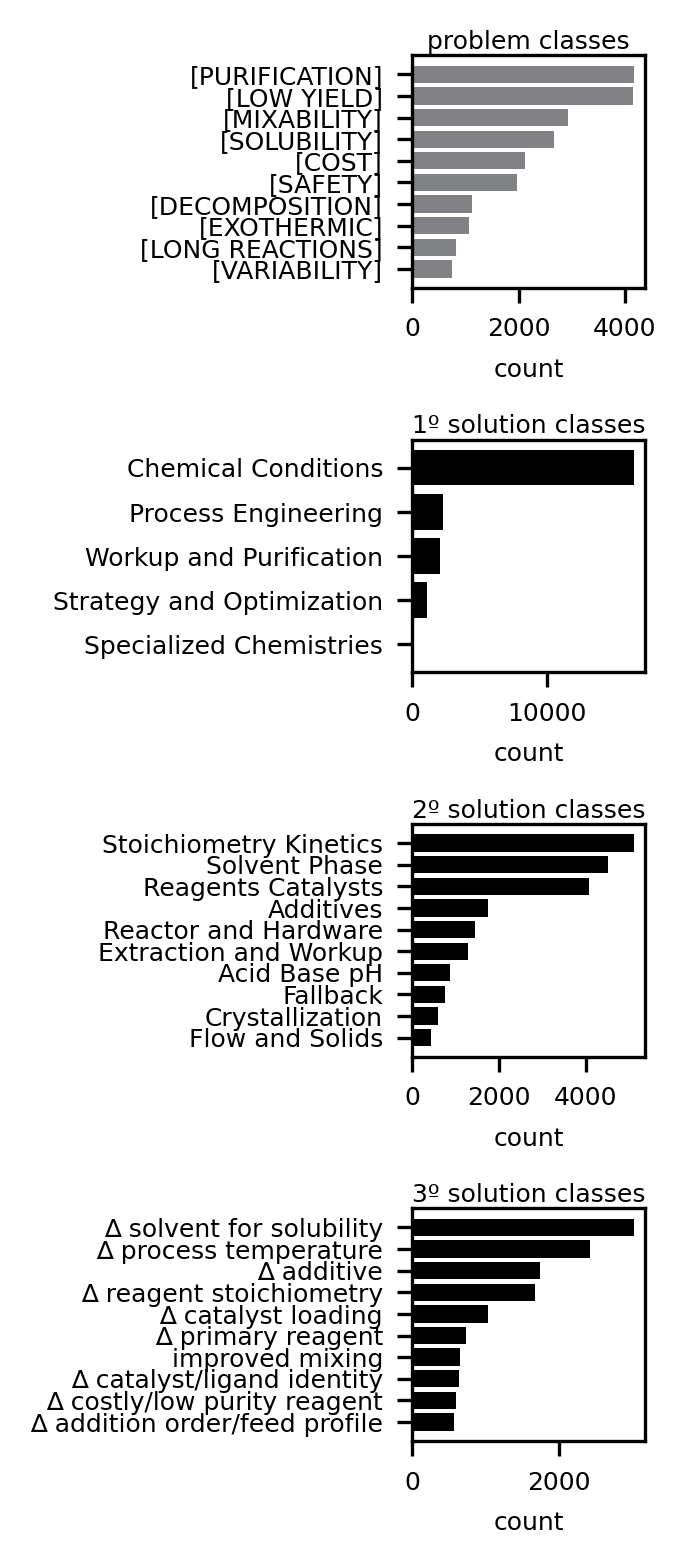

In [5]:
def pretty_label(label: str) -> str:
    label = label.replace("temperature_setpoint_or_temperature_ramp_optimization", "∆ process temperature")
    label = label.replace("catalyst_or_ligand", "catalyst/ligand")
    label = label.replace("improved_impurity_purge_or_byproduct_control", "impurity purge opt.")

    label = label.replace("improved_mixing_or_impeller_design", "improved mixing")
    label = label.replace("change_of_addition_order_or_feed_profile", "change_of_addition_order/feed_profile")
    label = label.replace("custom_or_novel_reactor_design","custom/novel_reactor_design")
    label = label.replace("replacement_of_costly_or_low_purity_reagent","replacement_of_costly/low_purity_reagent")
    label = label.replace("improved_quench_or_neutralization", "improved_quench")
    label = label.replace("crystallization_solvent_or_antisolvent_optimization", "crystallization_(anti)solvent_optimization")
    label = label.replace("drying_or_isolation_process_optimization", "drying/isolation_process_optimization")
    label = label.replace("insufficient_information_to_classify", "insufficient info")
    label = label.replace("change_of_", "∆ ")
    label = label.replace("solvent_change_", "∆ solvent ")
    label = label.replace("reagent_change_", "∆ reagent ")
    label = label.replace("optimization_of_", "∆ ")
    label = label.replace("replacement_of_", "∆ ")
    label = label.replace("optimization", "opt.")
    label = label.replace("_", " ")
    return label


def pretty_rxn_label(label):
    label = label.replace(" coupling", "")
    label = label.replace("Sulfonamide Schotten-Baumann", "Sulfonamide Schotten")
    label = label.replace("Other functional group addition","Other FGA")
    label = label.replace("Other organometallic C-C bond formation", "Other organomet. C-C formation")
    label = label.replace("Carboxylic acid to acid chloride", "Carb. acid to acid chloride")
    label = label.replace("Carboxylic ester + amine reaction", "Carb. ester/amine rxn.")
    label = label.replace("Carboxylic acid + amine condensation", "Carb. acid/amine cond.")
    label = label.replace("formation", "form.")
    label = label.replace("alkylation and arylation", "alkyl/arylation")
    label = label.replace("Functional group addition (FGA)", "FGA")
    label = label.replace("Functional group interconversion (FGI)", "FGI")
    label = label.replace("functional group interconversion", "FGI")
    label = label.replace("Acylation and related processes", "Acylation and related")
    label = label.replace("Other Pd-catalyzed reactions (Negishi,Kumada,etc.)","Other Pd-catalyzed")
    return label



def wrap_label(label: str, max_chars: int = 30) -> str:
    if len(label) <= max_chars:
        return label
    parts = label.split(" ")
    if len(parts) <= 4:
        return label
    return " ".join(parts[:4]) + "\n" + " ".join(parts[4:])


def nlines(label: str) -> int:
    return 2 if "\n" in label else 1


def plot_top_n_bars_for_columns(
    df,
    columns,
    top_n=10,
    *,
    figsize_per_col=(1.0, 3),
    save_path=None,
    color="grey",
):
    """
    Plot top-N value counts for any list of columns using horizontally arranged subplots.

    Parameters
    ----------
    df : pd.DataFrame
    columns : list[str]
        Columns to summarize and plot.
    top_n : int
        Number of most frequent values to display per column.
    figsize_per_col : tuple[float, float]
        Per-subplot (width, height). Total width scales with number of columns.
    save_path : str | None
        If provided, save figure with required export settings.
    color : str
        Bar color.
    """
    if not columns:
        raise ValueError("`columns` must contain at least one column name.")

    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    ncols = len(columns)
    fig_w = 1
    fig_h = 6

    with plt.rc_context({
        "font.size": 6,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
    }):
        fig, axes = plt.subplots(ncols, 1, figsize=(fig_w, fig_h), dpi=300, squeeze=False)
        axes = axes.ravel()
        colors = ["#808285", "black", "black", "black"]
        titles = ["problem classes", "1º solution classes", "2º solution classes", "3º solution classes"]
        n = 0
        for ax, col in zip(axes, columns):
            counts = df[col].dropna().astype(str).value_counts().head(top_n)
            labels = counts.index[::-1]
            values = counts.values[::-1]

            ax.barh(labels, values, color=colors[n])
            ax.set_title(titles[n], fontsize=6, y=0.92)
            ax.tick_params(axis="both", labelsize=6)
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels([pretty_label(l) for l in labels], rotation=0, ha="right")
            ax.set_ylabel("", fontsize=6)
            ax.set_xlabel("count", fontsize=6)
            n += 1
            # ax.set_yticks([])
            # ax.set_yticklabels([])

        # axes[0].set_ylabel("count", fontsize=6)
        # axes[0].set_yticks(range(0, max(values) + 1, max(1, max(values) // 5)))
        # axes[0].set_yticklabels([f"{v:,}" for v in range(0, max(values) + 1, max(1, max(values) // 5))], fontsize=5)
        # axes[1].set_xlabel("reaction code", fontsize=6)

        plt.subplots_adjust(hspace=0.65)

        if save_path is not None:
            fig.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.01,
            )

    return fig, axes


# Example usage:
fig, axes = plot_top_n_bars_for_columns(
    df_long,
    columns=["problemCategory", "solutionCat_L1", "solutionCat_L2", "solutionCategory"],
    top_n=10,
    save_path="figout/topN_any_columns_bars.png",
)
plt.show()

In [11]:
import ast
import re
import unicodedata
from collections import Counter

def _normalize_reagent_key(text):
    x = unicodedata.normalize("NFKC", str(text)).lower().strip()
    x = x.replace("–", "-").replace("—", "-").replace("‐", "-")
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9]+", "", x)
    return x

from reagent_hashmap import reagent_hashmap
def build_base_reagent_hash_map(custom_groups=None):
    """
    Build a hash map: normalized_variant -> canonical_name.

    custom_groups format:
      {canonical_name: [variant1, variant2, ...]}
    """
    base_groups = {
        "tetrahydrofuran": ["thf", "thf (solvent)", "tetrahydrofuran", "tetrahydrofuran (thf, solvent)"],
        "acetonitrile": ["acetonitrile", "acetonitrile (solvent)", "mecn"],
        "dichloromethane": ["dichloromethane", "dcm", "dichloromethane (solvent)"],
        "dimethylformamide": ["dmf", "dmf (solvent)", "dimethylformamide"],
        "methanol": ["methanol (solvent)", "methanol (meoh)", "meoh"],
        "water": ["water (solvent)", "water (reaction medium)", "water (h2o)", "water (quench)", "h2o"],
        "nitrogen atmosphere": ["nitrogen (inert atmosphere)", "n2", "nitrogen"],
        "triethylamine": ["triethylamine", "et3n"],
        "potassium carbonate": ["potassium carbonate", "k2co3"],
        "hydrochloric acid": ["hydrochloric acid", "hcl"],
        "sodium hydroxide": ["sodium hydroxide", "naoh", "naoh (wash)"],
        "sulfuric acid": ["sulfuric acid", "h2so4", "h2so4 (conc.)"],
        "acetic acid": ["acetic acid", "acoh"],
        "hydrogen gas": ["hydrogen", "h2", "h2 gas"],
        "isopropanol": ["isopropanol", "ipa", "2-propanol"],
        "2-methyltetrahydrofuran": ["methf", "-methf", "‐methf", "2-methf", "2-methyltetrahydrofuran"],
    }

    if custom_groups:
        for canonical, variants in custom_groups.items():
            if canonical not in base_groups:
                base_groups[canonical] = []
            base_groups[canonical].extend(variants)

    hash_map = {}
    for canonical, variants in base_groups.items():
        hash_map[_normalize_reagent_key(canonical)] = canonical
        for v in variants:
            hash_map[_normalize_reagent_key(v)] = canonical

    return hash_map

def build_reagent_hash_map():
    
    base_groups = {
        "tetrahydrofuran": ["thf", "thf (solvent)", "tetrahydrofuran", "tetrahydrofuran (thf, solvent)"],
        "acetonitrile": ["acetonitrile", "acetonitrile (solvent)", "mecn"],
        "dichloromethane": ["dichloromethane", "dcm", "dichloromethane (solvent)"],
        "dimethylformamide": ["dmf", "dmf (solvent)", "dimethylformamide"],
        "methanol": ["methanol (solvent)", "methanol (meoh)", "meoh"],
        "water": ["water (solvent)", "water (reaction medium)", "water (h2o)", "water (quench)", "h2o"],
        "nitrogen atmosphere": ["nitrogen (inert atmosphere)", "n2", "nitrogen"],
        "triethylamine": ["triethylamine", "et3n"],
        "potassium carbonate": ["potassium carbonate", "k2co3"],
        "hydrochloric acid": ["hydrochloric acid", "hcl"],
        "sodium hydroxide": ["sodium hydroxide", "naoh", "naoh (wash)"],
        "sulfuric acid": ["sulfuric acid", "h2so4", "h2so4 (conc.)"],
        "acetic acid": ["acetic acid", "acoh"],
        "hydrogen gas": ["hydrogen", "h2", "h2 gas"],
        "isopropanol": ["isopropanol", "ipa", "2-propanol"],
        "2-methyltetrahydrofuran": ["methf", "-methf", "‐methf", "2-methf", "2-methyltetrahydrofuran"],
    }
    
    for canonical, variants in base_groups.items():
        for ii in variants:
            if ii not in reagent_hashmap:
                reagent_hashmap[ii] = canonical

    return reagent_hashmap

def _standardize_reagent_name(name, reagent_hash_map=None):
    """Standardize a single reagent token for consistent counting."""
    reagent_hash_map = reagent_hash_map or {}

    x = unicodedata.normalize("NFKC", str(name)).strip().lower()
    x = x.replace("–", "-").replace("—", "-").replace("‐", "-")
    x = re.sub(r"^[\-•*\d\.\)\(\s]+", "", x)
    x = re.sub(r"\s+", " ", x)
    x = x.strip("'\" ")
    x = re.sub(r"\b(none|nan|null|n/a|na|unknown)\b", "", x).strip()

    if not x:
        return ""

    key = _normalize_reagent_key(x)
    if key in reagent_hash_map:
        return reagent_hash_map[key]
    # else:
        # print(key)

    return x

def _clean_unicode_token(token):
    x = unicodedata.normalize("NFKC", str(token))
    x = x.replace("‐", "-").replace("–", "-").replace("—", "-")
    x = re.sub(r"\s+", " ", x).strip()
    x = "".join(ch for ch in x if ch.isprintable())
    return x

def _safe_parse_reagents(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, str):
        txt = value.strip()
        if not txt:
            return []
        try:
            parsed = ast.literal_eval(txt)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
        except Exception:
            pass
        return [txt]
    return [str(value)]

def clean_standardize_and_count_reagents(
    df,
    *,
    reagent_col="reagents_used",
    reagent_hash_map=None,
    min_token_len=2,
    drop_single_char=True,
):
    """
    Clean + standardize the reagent list for every row and return reagent counts.

    Uses a normalization hash map to consolidate near-duplicate reagent names.
    """
    if reagent_col not in df.columns:
        raise ValueError(f"Missing reagent column: {reagent_col}")

    if reagent_hash_map is None:
        reagent_hash_map = build_reagent_hash_map()

    df_out = df.copy()

    cleaned_lists = []
    counter = Counter()
    hm = build_base_reagent_hash_map()
    ncount = 0
    for value in df_out[reagent_col]:
        parsed = _safe_parse_reagents(value)
        cleaned = []
        cleaned_split = []
        for raw in parsed:
            token = _clean_unicode_token(raw)
            if not token:
                ncount += 1
                cleaned.append("null")
                continue
            
            stds = _standardize_reagent_name(token, reagent_hash_map=hm)
            if stds in reagent_hash_map:
                stds = reagent_hash_map[stds]
            if not stds:
                ncount += 1
                cleaned.append("null")
                continue
            if len(stds) < min_token_len:
                ncount += 1
                cleaned.append("null")
                continue
            if drop_single_char and len(stds) == 1:
                ncount += 1
                cleaned.append("null")
                continue
            cleaned.append(stds)
            for std in stds.split(","):
                cleaned_split.append(std.strip())

        cleaned = sorted(set(cleaned))
        cleaned_lists.append(cleaned)
        counter.update(cleaned_split)
    print(ncount)
    df_out[f"{reagent_col}_clean"] = cleaned_lists
    df_out["n_reagents_clean"] = [len(x) for x in cleaned_lists]

    reagent_counts = (
        pd.DataFrame(counter.items(), columns=["reagent", "count"])
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    return df_out, reagent_counts


def plot_top_reagent_counts(
    reagent_counts,
    *,
    top_n=20,
    figsize=(1, 1),
    color="#808285",
    title="top standardized reagents",
    save_path=None,
):
    """Plot top-N standardized reagent counts with notebook style settings."""
    top = reagent_counts.head(top_n).copy()
    labels = [pretty_label(x) for x in top["reagent"].iloc[::-1]]
    values = top["count"].iloc[::-1].to_numpy()

    with plt.rc_context({
        "font.size": 6,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
    }):
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=300)
        ax.barh(labels, values, color=color)
        # ax.set_title(title, fontsize=6, y=0.96)
        ax.set_xlabel("count", fontsize=6)
        ax.set_ylabel("")
        ax.tick_params(axis="both", labelsize=6)
        plt.subplots_adjust(hspace=0.35)

        if save_path is not None:
            fig.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.01,
            )

    return fig, ax


reagent_hash_map = build_reagent_hash_map()
# print(len(reagent_hash_map))
df_long_clean, reagent_counts = clean_standardize_and_count_reagents(
    df_long,
    reagent_col="reagents_used",
    reagent_hash_map=reagent_hash_map,
)

display(reagent_counts.head(30))
print(reagent_counts["count"].sum())
# fig, ax = plot_top_reagent_counts(
#     reagent_counts,
#     top_n=20,
#     save_path="figout/top_standardized_reagents_consolidated.png",
# )
plt.show()
# failed to parse: 50313

50313


,reagent,count
0,water,11360
1,tetrahydrofuran,4333
2,methanol,2941
3,acetonitrile,2692
4,hydrochloric acid,2678
5,dichloromethane,2065
6,toluene,2029
7,ethanol,1977
8,sodium hydroxide,1881
9,dimethylformamide,1827


76415


In [77]:
reaction_class_reagents_cooccurrence = {}
for i,k in df_long_clean.iterrows():
    if k["reaction_class"] not in reaction_class_reagents_cooccurrence:
        reaction_class_reagents_cooccurrence[k["reaction_class"]] = Counter()
    for r in k["reagents_used_clean"]:
        for reag in r.split(","):
            reag = reag.strip()
            if reag not in reaction_class_reagents_cooccurrence[k["reaction_class"]]:
                reaction_class_reagents_cooccurrence[k["reaction_class"]][reag] = 0
            reaction_class_reagents_cooccurrence[k["reaction_class"]][reag] += 1

In [79]:
for k in reaction_class_reagents_cooccurrence:
    print(k)
    print(reaction_class_reagents_cooccurrence[k].most_common(6))
    print()

Unrecognized
[('null', 7226), ('water', 3456), ('tetrahydrofuran', 1488), ('acetonitrile', 1017), ('methanol', 802), ('hydrochloric acid', 775)]

Carboxylic acid to acid chloride
[('null', 84), ('thionyl chloride', 47), ('dimethylformamide', 38), ('dichloromethane', 38), ('oxalyl chloride', 31), ('water', 25)]

Carboxylic acid + amine condensation
[('null', 868), ('water', 361), ('dimethylformamide', 244), ('hydrochloric acid', 237), ('diisopropylethylamine', 216), ('acetonitrile', 161)]

Bromo Suzuki coupling
[('null', 523), ('water', 427), ('potassium phosphate', 199), ('tetrahydrofuran', 155), ('palladium catalyst', 155), ('palladium acetate', 143)]

Other separation
[('null', 3912), ('water', 2388), ('tetrahydrofuran', 713), ('methanol', 553), ('acetonitrile', 498), ('hydrochloric acid', 485)]

Amide Schotten-Baumann
[('null', 542), ('water', 250), ('dimethylformamide', 135), ('diisopropylethylamine', 109), ('tetrahydrofuran', 107), ('hydrochloric acid', 100)]

SNAr ether synthesis

In [168]:
# Export clean, parsable reagent list
dfr.to_csv(
    "reagents_standard_v1.csv",
    index=False,
    encoding="utf-8",
)
print("Saved: reagents_standard_v1.csv")

Saved: reagents_standard_v1.csv


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_value(value, counts, normalize=None, axis=None):
    """
    Normalize a value the same way pandas.crosstab(normalize=...) does.

    Parameters
    ----------
    value : float
        The raw count you want to normalize.
    counts : array-like or 2D array-like
        The full contingency table (raw counts).
    normalize : {None, 'all', 'index', 'columns', 0, 1, True}
        Same semantics as pd.crosstab.
    axis : int or None
        Required for 'index'/0 or 'columns'/1 normalization.
        For 'index'/0 → axis=1 (row sum)
        For 'columns'/1 → axis=0 (column sum)

    Returns
    -------
    float
        Normalized value.
    """
    import numpy as np

    if normalize is None or normalize is False:
        return value

    counts = np.asarray(counts)

    if normalize is True or normalize == "all":
        return value / counts.sum()

    if normalize in ("index", 0):
        if axis is None:
            raise ValueError("axis must be provided for index normalization")
        row_sum = counts.sum(axis=1)[axis]
        return value / row_sum

    if normalize in ("columns", 1):
        if axis is None:
            raise ValueError("axis must be provided for column normalization")
        col_sum = counts.sum(axis=0)[axis]
        return value / col_sum

    raise ValueError(f"Invalid normalize option: {normalize}")

def denormalize_value(norm_value, counts, normalize=None, axis=None):
    """
    Reverse normalization done by pd.crosstab(normalize=...).

    Parameters
    ----------
    norm_value : float
        The normalized value.
    counts : array-like or 2D array-like
        The original raw contingency table (needed for totals).
    normalize : {None, 'all', 'index', 'columns', 0, 1, True}
        Same semantics as pd.crosstab.
    axis : int or None
        Required for 'index'/0 or 'columns'/1 normalization.
        For 'index'/0 → axis = row index
        For 'columns'/1 → axis = column index

    Returns
    -------
    float
        Recovered raw count.
    """
    import numpy as np

    if normalize is None or normalize is False:
        return norm_value

    counts = np.asarray(counts)

    if normalize is True or normalize == "all":
        return norm_value * counts.sum()

    if normalize in ("index", 0):
        if axis is None:
            raise ValueError("axis must be provided for index normalization")
        row_sum = counts.sum(axis=1)[axis]
        return norm_value * row_sum

    if normalize in ("columns", 1):
        if axis is None:
            raise ValueError("axis must be provided for column normalization")
        col_sum = counts.sum(axis=0)[axis]
        return norm_value * col_sum

    raise ValueError(f"Invalid normalize option: {normalize}")

def save_cooccurrence_matrix(
    df,
    col_a,
    col_b,
    *,
    normalize=None,
    min_count=1.0,
    top_n=None,
    sort_by="frequency",
    figsize=(4.2, 3.8),
    cmap="copper",
    log_scale=False,
    matrix_save_path=None,
    fig_save_path=None,
    title=None,
    use_pretty_labels=True,
):
    """
    Build and save a co-occurrence matrix between any two columns.

    Parameters
    ----------
    df : pd.DataFrame
    col_a, col_b : str
        Column names for rows/columns in the co-occurrence matrix.
    normalize : {None, 'all', 'index', 'columns'}
        Passed to pd.crosstab(normalize=...).
    min_count : int
        Drop row/column labels whose total count is below this threshold.
    top_n : int | None
        Keep only the top-N row/column labels by raw frequency before plotting.
    sort_by : {'frequency', 'alphabetical'}
        How to order labels on each axis.
    figsize : tuple
        Matplotlib figure size.
    cmap : str
        Colormap for heatmap.
    log_scale : bool
        If True, display colors on a log1p scale while keeping colorbar labels in original units.
    matrix_save_path : str | None
        If provided, save matrix to CSV.
    fig_save_path : str | None
        If provided, save heatmap figure.
    title : str | None
        Custom title; default uses column names.
    use_pretty_labels : bool
        If True and pretty_label exists, prettify tick labels.

    Returns
    -------
    matrix : pd.DataFrame
    fig, ax : matplotlib Figure/Axes
    """
    required = {col_a, col_b}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if top_n is not None:
        if not isinstance(top_n, int) or top_n < 1:
            raise ValueError("top_n must be a positive integer or None")

    da_counts = df[col_a].value_counts()
    db_counts = df[col_b].value_counts()
    to_remove = []
    for idx, i in zip(da_counts.index, da_counts):
        if i < min_count:
            to_remove.append(idx)
    for idx, i in zip(db_counts.index, db_counts):
        if i < min_count:
            to_remove.append(idx)
    d = df[[col_a, col_b]]
    d = d[~d[col_a].isin(to_remove) & ~d[col_b].isin(to_remove)].copy()
    d = d.dropna().copy()
    d = d[d[col_b] != "Unrecognized"]
    d = d[d[col_b] != "Other separation"]

    if len(d) == 0:
        raise ValueError("No non-null rows available for selected columns.")

    matrix_unorm = pd.crosstab(
        d[col_a].astype(str),
        d[col_b].astype(str),
        normalize=False,
    )
    matrix = pd.crosstab(
        d[col_a].astype(str),
        d[col_b].astype(str),
        normalize=normalize,
    )
    if min_count > 0:
        if normalize is not None:
            norm_val = normalize_value(min_count, matrix_unorm, normalize=normalize)
            print(min_count, "->", norm_val)
            row_totals = matrix.sum(axis=1)
            col_totals = matrix.sum(axis=0)
            matrix = matrix.loc[row_totals >= norm_val, col_totals >= norm_val]
        else:
            row_totals = matrix.sum(axis=1)
            col_totals = matrix.sum(axis=0)
            matrix = matrix.loc[row_totals >= min_count, col_totals >= min_count]

    if top_n is not None:
        row_rank = matrix_unorm.sum(axis=1).sort_values(ascending=False).index.tolist()
        col_rank = matrix_unorm.sum(axis=0).sort_values(ascending=False).index.tolist()
        top_rows = [r for r in row_rank if r in matrix.index][:top_n]
        top_cols = [c for c in col_rank if c in matrix.columns][:top_n]
        matrix = matrix.loc[top_rows, top_cols]

    if sort_by == "frequency":
        matrix = matrix.loc[
            matrix.sum(axis=1).sort_values(ascending=False).index,
            matrix.sum(axis=0).sort_values(ascending=False).index,
        ]
    elif sort_by == "alphabetical":
        matrix = matrix.sort_index(axis=0).sort_index(axis=1)
    else:
        raise ValueError("sort_by must be one of: 'frequency', 'alphabetical'")

    if matrix.shape[0] == 0 or matrix.shape[1] == 0:
        raise ValueError("No data left after min_count/top_n filtering.")

    if matrix_save_path is not None:
        matrix.to_csv(matrix_save_path)

    with plt.rc_context(
        {
            "font.size": 6,
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial"],
        }
    ):
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=300)

        values = matrix.to_numpy(dtype=float)
        plot_values = np.log1p(values) if log_scale else values
        im = ax.imshow(plot_values, aspect="equal", cmap=cmap)

        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_yticks(np.arange(matrix.shape[0]))

            # new_labels = []
            # for l in labels:
            #     new_labels.append(reverse_rxn_code_lookup[l])
            # labels = new_labels

        reverse_rxn_code_lookup["Acid to acid chloride"] = "9.3.2"
        x_labels = matrix.columns.tolist()
        y_labels = matrix.index.tolist()
        if use_pretty_labels and "pretty_label" in globals():
            print(list(zip(x_labels,[reverse_rxn_code_lookup[v] for v in x_labels])))
            x_labels = [reverse_rxn_code_lookup[v] for v in x_labels]
            y_labels = [pretty_rxn_label(pretty_label(v)) for v in y_labels]

        ax.set_xticklabels(x_labels, rotation=90, ha="center")
        ax.set_yticklabels(y_labels)

        ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
        ax.grid(which="minor", color="black", linestyle="-", linewidth=0.3, alpha=0.35)
        ax.tick_params(which="minor", bottom=False, left=False)

        # ax.set_xlabel(col_b)
        # ax.set_ylabel(col_a)
        # ax.set_title(title or f"co-occurrence: {col_a} × {col_b}", y=0.98)

        # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        # cbar.ax.tick_params(labelsize=6)

        # if log_scale:
        #     if normalize is None or normalize is False:
        #         vmax_raw = float(np.nanmax(values))
        #         if vmax_raw <= 0:
        #             raw_ticks = np.array([0.0])
        #         else:
        #             geom_ticks = np.geomspace(1.0, vmax_raw, num=6)
        #             raw_ticks = np.unique(np.r_[0.0, np.round(geom_ticks)])
        #             raw_ticks = raw_ticks[raw_ticks <= vmax_raw]
        #             if raw_ticks[-1] != vmax_raw:
        #                 raw_ticks = np.r_[raw_ticks, vmax_raw]
        #         cbar_ticks = np.log1p(raw_ticks)
        #         cbar.set_ticks(cbar_ticks.tolist())
        #         cbar.set_ticklabels([f"{t:.0f}" for t in raw_ticks])
        #     else:
        #         vmin_raw = float(np.nanmin(values))
        #         vmax_raw = float(np.nanmax(values))
        #         raw_ticks = np.linspace(vmin_raw, vmax_raw, num=6)
        #         cbar_ticks = np.log1p(raw_ticks)
        #         cbar.set_ticks(cbar_ticks.tolist())
        #         cbar.set_ticklabels([
        #             f"{denormalize_value(t, matrix_unorm, normalize=normalize):.0f}"
        #             for t in raw_ticks
        #         ])
        # elif normalize is not None:
        #     cbar_ticks = np.asarray(cbar.get_ticks(), dtype=float)
        #     cbar.set_ticks(cbar_ticks.tolist())
        #     cbar.set_ticklabels([
        #         f"{denormalize_value(t, matrix_unorm, normalize=normalize):.0f}"
        #         for t in cbar_ticks
        #     ])
        ax.yaxis.tick_right()
        ax.tick_params(axis="y", which="major", left=False, right=True, labelleft=False, labelright=True)
        ax.tick_params(axis="y", which="minor", left=False, right=False, labelleft=False, labelright=False)

        if fig_save_path is not None:
            fig.savefig(
                fig_save_path,
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.01,
            )

    return matrix, fig, ax


# Example usage:
cooc, fig, ax = save_cooccurrence_matrix(
    df_long,
    "problemCategory",
    "reaction_class",
    min_count=0,
    top_n=24,
    cmap="Greys",
    normalize=False,
    log_scale=True,
    sort_by="frequency",
    matrix_save_path="figout/problem_vs_solution_cooccurrence.csv",
    fig_save_path="figout/problem_vs_solution_cooccurrence.png",
)
# plt.show()

[('Carboxylic acid + amine condensation', '2.1.2'), ('Amide Schotten-Baumann', '2.1.1'), ('Bromo Suzuki coupling', '3.1.1'), ('SNAr ether synthesis', '1.7.11'), ('Esterification', '2.6.2'), ('Ring closing olefin metathesis', '3.9.121'), ('Nitro to amino', '7.1.1'), ('Alkene hydrogenation', '7.6.1'), ('Ester hydrolysis', '9.7.61'), ('Ketone to alcohol reduction', '7.5.1'), ('N-Boc deprotection', '6.1.1'), ('Bromo Buchwald-Hartwig amination', '1.3.1'), ('Acid to acid chloride', '9.3.2'), ('Bromination', '10.1.1'), ('Chlorination', '10.1.2'), ('Hydroamination', '1.2.17'), ('Bromo N-alkylation', '1.6.2'), ('Alcohol to aldehyde oxidation', '8.1.4'), ('Carbamate Schotten-Baumann', '2.4.5'), ('Racemization', '11.7'), ('Aldehyde reductive amination', '1.2.1'), ('Amide hydrolysis', '9.7.351'), ('Bromo Suzuki-type coupling', '3.1.5'), ('Carboxylic acid to acid chloride', '9.3.1')]
